    Цель проекта

Провести анализ клинико-демографических признаков пациентов с различными типами рака кожи и построить модель машинного обучения, которая на основе этих неинвазивных данных (возраст, пол, локализация, анамнез) может предположить наиболее вероятный тип злокачественного новообразования до проведения биопсии.

    Исследовательский вопрос (гипотеза)

Существуют ли статистически значимые различия в профилях пациентов с разными типами рака кожи (BCC, MEL, SCC), которые позволяют с достаточной точностью дифференцировать их на этапе клинического осмотра?

    Ограничение (этическое и клиническое)

Модель не предназначена для постановки окончательного диагноза и не заменяет гистологическое исследование. Её цель — помочь врачу в формировании предварительного заключения и маршрутизации пациента.

Number of attributes: 26

1) patient_id: Identifier of the patient under study.

2) lesion_id: Identifier of the lesion or wound under study in the patient.

3) smoke: Whether the patient has a history of smoking or not.

4) drink: Whether the patient has a history of alcohol consumption or not.

5) background_father: The history of any diseases or health conditions related to the patient's father, including any history of skin cancer or other diseases that may be related to skin cancer.

6) background_mother: The history of any diseases or health conditions related to the patient's mother, including any history of skin cancer or other diseases that may be related to skin cancer.

7) age: Age of the patient at the time of examination.

8) pesticide: Whether the patient has been exposed to pesticides or other chemicals.

9) gender: Gender of the patient.

10) skin_cancer_history: History of skin cancer in the patient's family.

11) cancer_history: History of cancer in the patient's family.

12) has_piped_water: Indicates whether the location or area of the patient's residence has access to piped water or not.

13) has_sewage_system: Indicates whether the location or area of the patient's residence has a proper sewage system or not.

14) fitspatrick: Skin tolerance to sunlight.

15) region: The area of the body where the lesion or wound has been examined.

16) diameter_1: Primary diameter of the lesion or wound.

17) diameter_2: Secondary diameter of the lesion or wound.

18) diagnostic: The type of lesion or wound is diagnosed.

19) itch: Whether the lesion or wound has itched or not.

20) grew: Whether the size of the lesion or wound has grown or not.

21) hurt: Whether the lesion or wound has hurt or not.

22) changed: Whether the appearance of the lesion or wound has changed or not.

23) bleed: Whether the lesion or wound has bled or not.

24) elevation: Description of the of the lesion or wound relative to the skin surface of the patient.

25) img_id: Identifier of the image related to the lesion or wound.

26) biopsed: Whether the lesion or wound has been biopsied or not.

In [1]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

In [3]:
data = pd.read_csv('metadata.csv')

In [4]:
data.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2298 entries, 0 to 2297
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2298 non-null   object 
 1   lesion_id            2298 non-null   int64  
 2   smoke                1494 non-null   object 
 3   drink                1494 non-null   object 
 4   background_father    1480 non-null   object 
 5   background_mother    1476 non-null   object 
 6   age                  2298 non-null   int64  
 7   pesticide            1494 non-null   object 
 8   gender               1494 non-null   object 
 9   skin_cancer_history  1494 non-null   object 
 10  cancer_history       1494 non-null   object 
 11  has_piped_water      1494 non-null   object 
 12  has_sewage_system    1494 non-null   object 
 13  fitspatrick          1494 non-null   float64
 14  region               2298 non-null   object 
 15  diameter_1           1494 non-null   f

In [6]:
data.duplicated().sum()

0

In [7]:
data.isnull().sum()

patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed                    0
elevation                0
img_id                   0
biopsed                  0
dtype: int64

Удаляю строки с пропусками. Это спорный момент, но останется почти 1.5 тыс значений, этого вполне хватит для дальнейшего изучения. ТОлько нужно проверить, не повлияло ли это значительно на распределение целевой переменной.

In [8]:
print(data['diagnostic'].value_counts())
print(data['diagnostic'].value_counts(normalize=True) * 100)

BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: diagnostic, dtype: int64
BCC    36.771105
ACK    31.766754
NEV    10.617929
SEK    10.226284
SCC     8.355091
MEL     2.262837
Name: diagnostic, dtype: float64


In [9]:
data = data.dropna()

In [10]:
print(data['diagnostic'].value_counts())
print(data['diagnostic'].value_counts(normalize=True) * 100)

BCC    845
ACK    273
SCC    192
NEV     72
MEL     52
SEK     40
Name: diagnostic, dtype: int64
BCC    57.327001
ACK    18.521031
SCC    13.025780
NEV     4.884668
MEL     3.527815
SEK     2.713704
Name: diagnostic, dtype: float64


После удаления пропусков распределение классов целевой переменной сильно изменилось. Однако все случаи злокачественных образований остались неизменными. Учитывая образовательную цель данного проекта, оставляем вариант без пропусков для удобства работы.

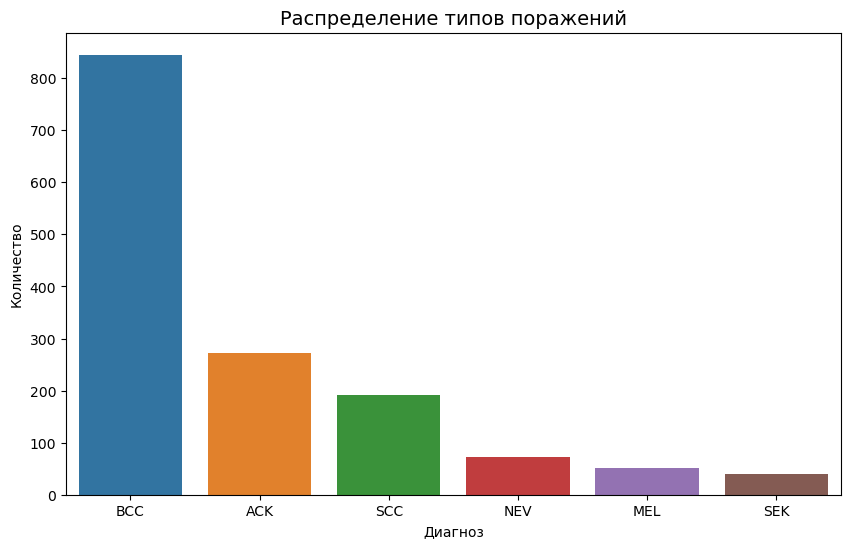

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='diagnostic', data=data, order=data['diagnostic'].value_counts().index)
plt.title('Распределение типов поражений', fontsize=14)
plt.xlabel('Диагноз')
plt.ylabel('Количество')
plt.show()

Нужно удалить явно неинформативные столбцы. Это 'img_id', 'patient_id', 'lesion_id', 'biopsed'. 

In [12]:
cols_to_drop = ['img_id', 'patient_id', 'lesion_id', 'biopsed']
data = data.drop(columns=cols_to_drop)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1474 entries, 1 to 2296
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   smoke                1474 non-null   object 
 1   drink                1474 non-null   object 
 2   background_father    1474 non-null   object 
 3   background_mother    1474 non-null   object 
 4   age                  1474 non-null   int64  
 5   pesticide            1474 non-null   object 
 6   gender               1474 non-null   object 
 7   skin_cancer_history  1474 non-null   object 
 8   cancer_history       1474 non-null   object 
 9   has_piped_water      1474 non-null   object 
 10  has_sewage_system    1474 non-null   object 
 11  fitspatrick          1474 non-null   float64
 12  region               1474 non-null   object 
 13  diameter_1           1474 non-null   float64
 14  diameter_2           1474 non-null   float64
 15  diagnostic           1474 non-null   o

    Инвентаризация данных

In [14]:
data.describe()

,age,fitspatrick,diameter_1,diameter_2
count,1474.000000,1474.000000,1474.000000,1474.000000
mean,63.044776,2.255088,11.910583,8.865129
std,14.465988,0.721170,8.679941,5.822623
min,13.000000,1.000000,0.000000,0.000000
25%,54.000000,2.000000,7.000000,5.000000
50%,64.000000,2.000000,10.000000,8.000000
75%,73.000000,3.000000,15.000000,10.000000
max,94.000000,6.000000,100.000000,70.000000


In [15]:
zero_diameter = data[(data['diameter_1'] == 0) | (data['diameter_2'] == 0)]
print(len(zero_diameter))
zero_diameter[['diameter_1', 'diameter_2', 'diagnostic']].head(10)

4


,diameter_1,diameter_2,diagnostic
363,0.0,0.0,BCC
1470,0.0,0.0,SCC
2113,0.0,0.0,BCC
2129,0.0,0.0,BCC


In [16]:
data = data[(data['diameter_1'] != 0) | (data['diameter_2'] != 0)]

In [17]:
categorical_cols = data.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n {col} ")
    print(data[col].value_counts().head())
    print(f"Уникальных значений: {data[col].nunique()}")


 smoke 
False    1270
True      200
Name: smoke, dtype: int64
Уникальных значений: 2

 drink 
False    1112
True      358
Name: drink, dtype: int64
Уникальных значений: 2

 background_father 
POMERANIA    527
GERMANY      462
ITALY        248
UNK           94
BRAZIL        89
Name: background_father, dtype: int64
Уникальных значений: 13

 background_mother 
POMERANIA    531
GERMANY      480
ITALY        234
UNK           84
BRAZIL        81
Name: background_mother, dtype: int64
Уникальных значений: 11

 pesticide 
False    878
True     592
Name: pesticide, dtype: int64
Уникальных значений: 2

 gender 
FEMALE    746
MALE      724
Name: gender, dtype: int64
Уникальных значений: 2

 skin_cancer_history 
False    796
True     674
Name: skin_cancer_history, dtype: int64
Уникальных значений: 2

 cancer_history 
True     774
False    696
Name: cancer_history, dtype: int64
Уникальных значений: 2

 has_piped_water 
True     904
False    566
Name: has_piped_water, dtype: int64
Уникальных значен

In [18]:
symptom_cols = ['itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
for col in symptom_cols:
    data[col] = data[col].replace('UNK', 'FALSE')

In [19]:
sun_exposed_regions = ['FACE', 'NOSE', 'EAR', 'SCALP', 'FOREARM', 'NECK', 'HAND']
data['sun_exposed'] = data['region'].apply(lambda x: 1 if x in sun_exposed_regions else 0)
data = data.drop(columns='region')

In [20]:
bool_cols = ['smoke', 'drink', 'pesticide', 'skin_cancer_history', 
             'cancer_history', 'has_piped_water', 'has_sewage_system']
for col in bool_cols:
    data[col] = data[col].astype(int)

symptom_cols = ['itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
for col in symptom_cols:
    data[col] = data[col].map({'TRUE': 1, 'FALSE': 0})

data['gender'] = data['gender'].map({'MALE': 0, 'FEMALE': 1})

In [21]:
print(data['background_father'].unique())
print(data['background_mother'].unique())

['POMERANIA' 'GERMANY' 'BRAZIL' 'NETHERLANDS' 'ITALY' 'POLAND' 'UNK'
 'PORTUGAL' 'BRASIL' 'CZECH' 'AUSTRIA' 'SPAIN' 'ISRAEL']
['POMERANIA' 'ITALY' 'GERMANY' 'BRAZIL' 'UNK' 'POLAND' 'NORWAY' 'PORTUGAL'
 'NETHERLANDS' 'FRANCE' 'SPAIN']


    Содержимое не соответствет названию столбца. Есть информация и типе кожи и фоточувствительности. Учитывая это и сильную миграцию, эти столбцы можно удалить как неинформативные.

In [22]:
data = data.drop(columns=['background_father', 'background_mother'])

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1470 entries, 1 to 2296
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   smoke                1470 non-null   int64  
 1   drink                1470 non-null   int64  
 2   age                  1470 non-null   int64  
 3   pesticide            1470 non-null   int64  
 4   gender               1470 non-null   int64  
 5   skin_cancer_history  1470 non-null   int64  
 6   cancer_history       1470 non-null   int64  
 7   has_piped_water      1470 non-null   int64  
 8   has_sewage_system    1470 non-null   int64  
 9   fitspatrick          1470 non-null   float64
 10  diameter_1           1470 non-null   float64
 11  diameter_2           1470 non-null   float64
 12  diagnostic           1470 non-null   object 
 13  itch                 1470 non-null   int64  
 14  grew                 1470 non-null   int64  
 15  hurt                 1470 non-null   i

Данные очищены и подготовлены.

        Двумерный анализ

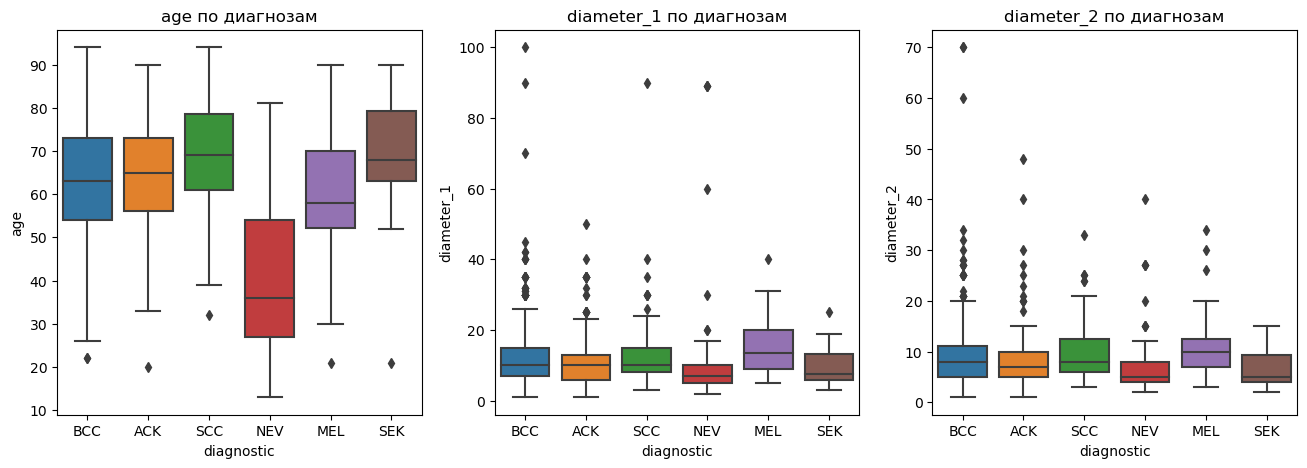

Результаты теста Краскела-Уоллиса:
age: H-статистика = 146.15, p-value = 0.0000
diameter_1: H-статистика = 48.56, p-value = 0.0000
diameter_2: H-статистика = 52.19, p-value = 0.0000


In [24]:
num_features = ['age', 'diameter_1', 'diameter_2']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feature in zip(axes, num_features):
    sns.boxplot(x='diagnostic', y=feature, data=data, ax=ax,
                order=data['diagnostic'].value_counts().index)
    ax.set_title(f'{feature} по диагнозам')
    ax.tick_params(axis='x')
plt.show()

print("Результаты теста Краскела-Уоллиса:")
for feature in num_features:
    groups = [group[feature].values for name, group in data.groupby('diagnostic')]
    h_stat, p_val = stats.kruskal(*groups)
    print(f"{feature}: H-статистика = {h_stat:.2f}, p-value = {p_val:.4f}")

Тест показал значимые различия, хотя по графикам это не так очевидно. Проведем попарные сравнения по возрасту (тест Данна с поправкой Холма)

In [25]:
dunn_results = sp.posthoc_dunn(data, val_col='age', group_col='diagnostic', p_adjust='holm')
print(dunn_results)

              ACK           BCC       MEL           NEV           SCC  \
ACK  1.000000e+00  2.736185e-01  0.103609  1.281279e-20  5.596248e-03   
BCC  2.736185e-01  1.000000e+00  0.273619  4.061505e-20  1.261332e-06   
MEL  1.036089e-01  2.736185e-01  1.000000  4.295315e-06  1.843412e-04   
NEV  1.281279e-20  4.061505e-20  0.000004  1.000000e+00  2.779487e-29   
SCC  5.596248e-03  1.261332e-06  0.000184  2.779487e-29  1.000000e+00   
SEK  1.194620e-01  1.947725e-02  0.005151  1.201572e-15  7.675092e-01   

              SEK  
ACK  1.194620e-01  
BCC  1.947725e-02  
MEL  5.150556e-03  
NEV  1.201572e-15  
SCC  7.675092e-01  
SEK  1.000000e+00  


1. **NEV значимо моложе всех остальных групп.**  
   Все p-value в строке NEV экстремально малы (от 10^-15 до 10^-29), что подтверждает: пациенты с невусами статистически моложе пациентов с любым другим типом поражений.

2. **BCC и SCC различаются по возрасту.**  
   p-value для пары BCC и SCC = 0.0000013. Пациенты с базальноклеточной карциномой статистически значимо старше пациентов с плоскоклеточной карциномой.

3. **ACK не отличается по возрасту от BCC и MEL.**  
   Для пар ACK и BCC (p = 0.27) и ACK и MEL (p = 0.10) p-value > 0.05. Нет оснований утверждать, что возраст пациентов с актиническим кератозом значимо отличается от возраста пациентов с базальноклеточной карциномой или меланомой.

Проверяем, какие бинарные и категориальные признаки статистически связаны с типом поражения.

Тест Хи-квадрат для таблиц сопряжённости.

In [26]:
cat_features = [
    'smoke', 'drink', 'pesticide', 'gender', 'skin_cancer_history',
    'cancer_history', 'has_piped_water', 'has_sewage_system',
    'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation',
    'sun_exposed', 'fitspatrick'
]

for feature in cat_features:
    cross_tab = pd.crosstab(data[feature], data['diagnostic'])
    chi2, p_val, dof, expected = stats.chi2_contingency(cross_tab)
    print(f"{feature:25s}: chi2 = {chi2:7.2f}, p-value = {p_val:.4f}")

smoke                    : chi2 =   27.13, p-value = 0.0001
drink                    : chi2 =    7.45, p-value = 0.1893
pesticide                : chi2 =   26.12, p-value = 0.0001
gender                   : chi2 =   15.22, p-value = 0.0095
skin_cancer_history      : chi2 =   10.94, p-value = 0.0526
cancer_history           : chi2 =    4.98, p-value = 0.4181
has_piped_water          : chi2 =   11.85, p-value = 0.0369
has_sewage_system        : chi2 =   12.72, p-value = 0.0261
itch                     : chi2 =  245.75, p-value = 0.0000
grew                     : chi2 =   74.98, p-value = 0.0000
hurt                     : chi2 =  123.92, p-value = 0.0000
changed                  : chi2 =  162.19, p-value = 0.0000
bleed                    : chi2 =  226.39, p-value = 0.0000
elevation                : chi2 =  263.49, p-value = 0.0000
sun_exposed              : chi2 =   83.50, p-value = 0.0000
fitspatrick              : chi2 =  106.95, p-value = 0.0000


Проверяем, нет ли среди отобранных числовых и бинарных признаков сильно связанных друг с другом.
Пары с корреляцией выше 0.8 будем рассматривать к удалению одного из признаков.

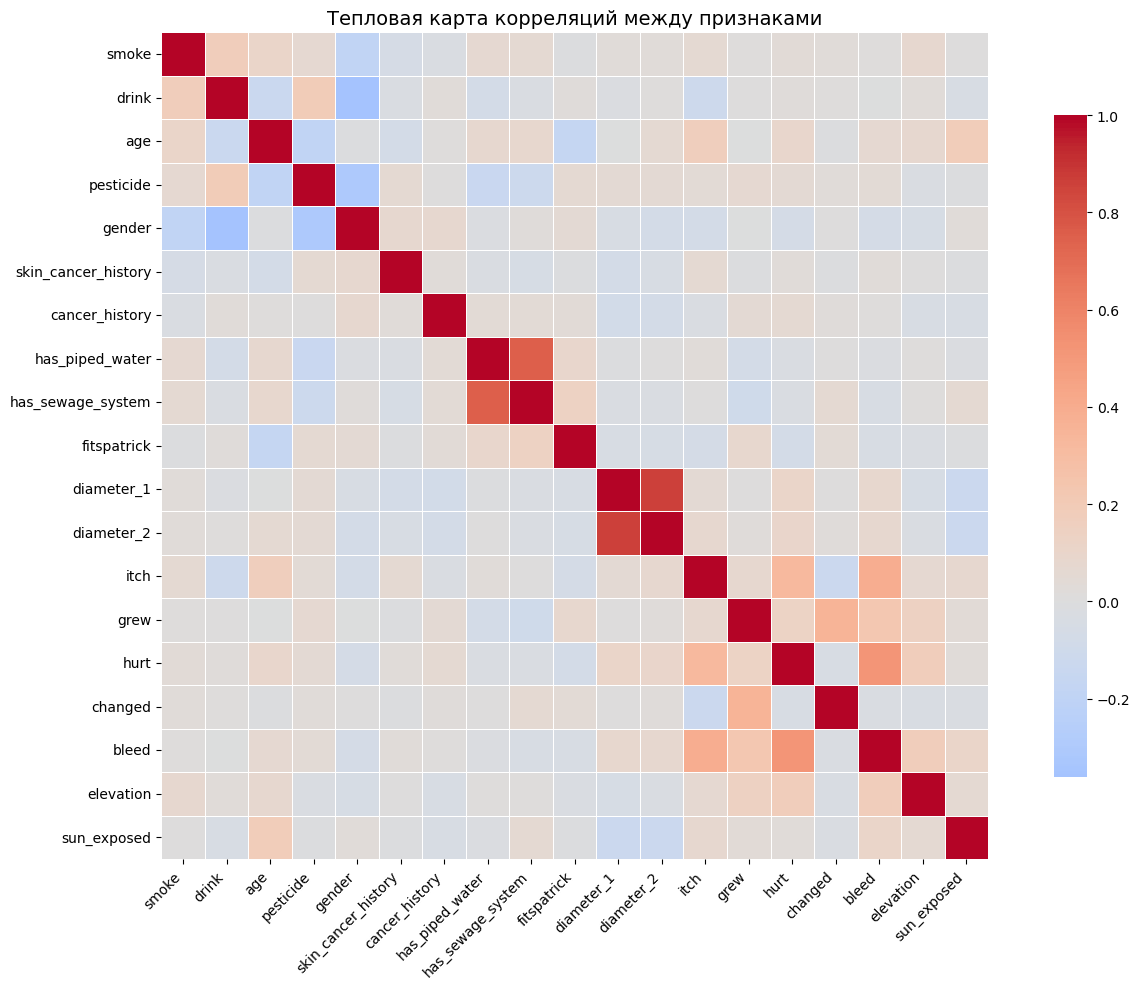

In [27]:
corr_features = [col for col in data.columns if col != 'diagnostic']

corr_matrix = data[corr_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций между признаками', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]:25s} и {pair[1]:25s}: r = {pair[2]:.3f}")
else:
    print("Пар с экстремально высокой корреляцией не найдено.")

diameter_1                и diameter_2               : r = 0.857


In [29]:
data = data.drop(columns=['diameter_2'])

Создаём четырёхклассовую целевую переменную:

- 0 — не рак (ACK, NEV, SEK)
- 1 — BCC
- 2 — MEL
- 3 — SCC

In [30]:
df_model = data.copy()

cancer_types = ['BCC', 'MEL', 'SCC']

def map_target(diagnostic):
    if diagnostic in cancer_types:
        return cancer_types.index(diagnostic) + 1 
    else:
        return 0 

df_model['target'] = df_model['diagnostic'].apply(map_target)

In [31]:
df_model['target'].value_counts().sort_index()

0    385
1    842
2     52
3    191
Name: target, dtype: int64

In [32]:
X = df_model.drop(columns=['diagnostic', 'target'])
y = df_model['target']

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [34]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_lr.fit(X_train, y_train)

y_train_pred = model_lr.predict(X_train)
y_val_pred = model_lr.predict(X_val)

/Users/lena/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
classes = [0, 1, 2, 3]
class_names = ['Не рак', 'BCC', 'MEL', 'SCC']

precisions = precision_score(y_val, y_val_pred, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.66, Recall=0.52, F1=0.58
BCC: Precision=0.68, Recall=0.90, F1=0.78
MEL: Precision=0.50, Recall=0.36, F1=0.42
SCC: Precision=0.00, Recall=0.00, F1=0.00
Accuracy: 0.67


Базовая логистическая регрессия без дополнительных настроек показала:
- BCC определяется хорошо (Recall 0.90).
- Не рак удовлетворительно (Recall 0.52, Precision 0.66).
- MEL плохо (Recall 0.36). Модель пропускает почти две трети меланом, что критически важно клинически.
- SCC полностью проигнорирован (Recall 0.00). Модель не предсказала ни одного SCC из-за дисбаланса классов.

Общая Accuracy (0.67) неинформативна, так как классы сильно несбалансированы. Основные проблемы — игнорирование редких классов MEL и SCC. Попытаемся улучшить модель с помощью учёта дисбаланса классов.

In [36]:
model_lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

model_lr_balanced.fit(X_train, y_train)

y_val_pred_bal = model_lr_balanced.predict(X_val)

precisions = precision_score(y_val, y_val_pred_bal, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_bal, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_bal, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_bal)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.52, Recall=0.51, F1=0.51
BCC: Precision=0.74, Recall=0.49, F1=0.59
MEL: Precision=0.31, Recall=0.82, F1=0.45
SCC: Precision=0.20, Recall=0.42, F1=0.27
Accuracy: 0.50


/Users/lena/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Модель лучше выявляет злокачественные новообразования, реже пропускает меланому. Однако стало больше "ложных тревог". 

In [37]:
model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_val_pred_rf = model_rf.predict(X_val)

precisions = precision_score(y_val, y_val_pred_rf, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_rf, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_rf, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_rf)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.70, Recall=0.57, F1=0.63
BCC: Precision=0.74, Recall=0.89, F1=0.81
MEL: Precision=0.62, Recall=0.45, F1=0.53
SCC: Precision=0.65, Recall=0.34, F1=0.45
Accuracy: 0.72


Random Forest без дополнительных настроек показал себя лучше логистической регрессии:

Ансамблевый метод лучше справляется с дисбалансом классов даже без дополнительных настроек. Однако Recall для MEL и SCC всё ещё недостаточно высок. Попробуем Random Forest с балансировкой классов.

In [38]:
model_rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')

model_rf_balanced.fit(X_train, y_train)

y_val_pred_rf_bal = model_rf_balanced.predict(X_val)

precisions = precision_score(y_val, y_val_pred_rf_bal, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_rf_bal, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_rf_bal, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_rf_bal)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.73, Recall=0.60, F1=0.66
BCC: Precision=0.74, Recall=0.90, F1=0.81
MEL: Precision=0.86, Recall=0.55, F1=0.67
SCC: Precision=0.67, Recall=0.37, F1=0.47
Accuracy: 0.74


In [39]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=3, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}


In [40]:
model_rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model_rf_tuned.fit(X_train, y_train)

y_val_pred_rf_tuned = model_rf_tuned.predict(X_val)

precisions = precision_score(y_val, y_val_pred_rf_tuned, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_rf_tuned, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_rf_tuned, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_rf_tuned)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.69, Recall=0.62, F1=0.65
BCC: Precision=0.78, Recall=0.86, F1=0.82
MEL: Precision=0.43, Recall=0.55, F1=0.48
SCC: Precision=0.62, Recall=0.39, F1=0.48
Accuracy: 0.73


С подобранными гиперпараметрами оптимизация взвешенного F1 привела к падению Precision для MEL (0.43) и SCC (0.62), хотя Recall практически не изменился. Модель стала чаще давать ложные тревоги, что клинически менее желательно. Остемся с моделью с балансировкой без подобранных гиперпараметров.

In [41]:
model_lgbm = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

model_lgbm.fit(X_train, y_train)

y_val_pred_lgbm = model_lgbm.predict(X_val)

precisions = precision_score(y_val, y_val_pred_lgbm, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_lgbm, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_lgbm, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_lgbm)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.67, Recall=0.62, F1=0.64
BCC: Precision=0.79, Recall=0.84, F1=0.81
MEL: Precision=0.55, Recall=0.55, F1=0.55
SCC: Precision=0.50, Recall=0.42, F1=0.46
Accuracy: 0.72


In [42]:
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, -1],
    'learning_rate': [0.05, 0.1],
    'min_child_samples': [5, 10]
}

lgbm_base = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

grid_search_lgbm = GridSearchCV(
    lgbm_base, param_grid_lgbm,
    cv=3, scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search_lgbm.fit(X_train, y_train)

print(grid_search_lgbm.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 200}


In [43]:
model_lgbm_tuned = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.05,
    min_child_samples=10,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

model_lgbm_tuned.fit(X_train, y_train)

y_val_pred_lgbm_tuned = model_lgbm_tuned.predict(X_val)

precisions = precision_score(y_val, y_val_pred_lgbm_tuned, average=None, labels=classes)
recalls = recall_score(y_val, y_val_pred_lgbm_tuned, average=None, labels=classes)
f1s = f1_score(y_val, y_val_pred_lgbm_tuned, average=None, labels=classes)
acc = accuracy_score(y_val, y_val_pred_lgbm_tuned)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.63, Recall=0.58, F1=0.61
BCC: Precision=0.77, Recall=0.83, F1=0.80
MEL: Precision=0.50, Recall=0.55, F1=0.52
SCC: Precision=0.47, Recall=0.37, F1=0.41
Accuracy: 0.70


Лучшая модель Random Forest с `class_weight='balanced'` без дополнительного подбора гиперпараметров.

- Лучший F1 для MEL (0.67) — самого важного класса с клинической точки зрения.
- Высокий Precision для MEL (0.86) — модель редко ошибается, когда предсказывает меланому.
- Самый высокий общий Accuracy (0.74) при сохранении хорошего баланса по всем классам.
- LightGBM с подбором гиперпараметров не превзошёл Random Forest, показав худшие результаты по MEL (F1=0.52) и SCC (F1=0.41).

In [44]:
y_test_pred = model_rf_balanced.predict(X_test)

precisions = precision_score(y_test, y_test_pred, average=None, labels=classes)
recalls = recall_score(y_test, y_test_pred, average=None, labels=classes)
f1s = f1_score(y_test, y_test_pred, average=None, labels=classes)
acc = accuracy_score(y_test, y_test_pred)

for i, name in enumerate(class_names):
    print(f"{name}: Precision={precisions[i]:.2f}, Recall={recalls[i]:.2f}, F1={f1s[i]:.2f}")
print(f"Accuracy: {acc:.2f}")

Не рак: Precision=0.65, Recall=0.69, F1=0.67
BCC: Precision=0.79, Recall=0.86, F1=0.83
MEL: Precision=0.80, Recall=0.40, F1=0.53
SCC: Precision=0.79, Recall=0.50, F1=0.61
Accuracy: 0.76


Модель Random Forest с балансировкой классов (`class_weight='balanced'`) показала на тестовой выборке следующие результаты:

- **BCC (базальноклеточная карцинома):** определяется отлично (Recall 0.86, F1=0.83). Это самый частый класс, и модель уверенно его находит.
- **Не рак (доброкачественные и предраковые):** хорошее качество (Recall 0.69, F1=0.67). Модель правильно определяет примерно две трети незлокачественных поражений.
- **SCC (плоскоклеточная карцинома):** удовлетворительно (Recall 0.50, F1=0.61). Половина случаев SCC обнаруживается, и когда модель предсказывает SCC, она права в 79% случаев.
- **MEL (меланома):** Precision 0.80, но Recall 0.40 (F1=0.53). Модель очень осторожна в предсказании меланомы: когда она говорит «это меланома», она права в 80% случаев. Но она находит только 40% реальных меланом. Это означает, что модель не может использоваться для исключения меланомы — она слишком часто её пропускает. Однако высокая точность положительных предсказаний делает её полезной для предварительного скрининга и маршрутизации пациентов на дополнительные обследования.

**Общий вывод:**
Построенная модель решает задачу дифференциации трёх типов рака кожи и доброкачественных поражений на основе клинико-демографических признаков. Наибольшую практическую ценность она представляет для выявления BCC (высокий Recall) и для подтверждения меланомы (высокий Precision). Основное ограничение — низкий Recall для меланомы и SCC, что связано с сильным дисбалансом классов в обучающих данных. Дальнейшие шаги по улучшению: сбор дополнительных примеров редких классов, использование специфических дерматоскопических признаков, применение методов oversampling (SMOTE) или ансамблей с фокусом на редкие классы.